KNN — K Nearest Neighbors Classifier

In [30]:
import pandas as pd
import numpy as np
from category_encoders import BinaryEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score, roc_auc_score
from sklearn.utils import resample

cls_df = pd.read_csv(r"C:\B_I_FINAL_PROJECT\Data_CancerRx_Predictor_CLEAN_DATA\gdsc1_classification.csv")

nominal_columns = [ "TCGA_DESC", "GDSC Tissue descriptor 1", "GDSC Tissue descriptor 2",
    "Cancer Type (matching TCGA label)", "TARGET", "TARGET_PATHWAY",
    "Screen Medium", "Growth Properties", "Microsatellite instability Status (MSI)"]

be_cls = BinaryEncoder(cols=nominal_columns)
X_cls = be_cls.fit_transform(cls_df[nominal_columns]).to_numpy()
y_cls = cls_df["SENSITIVE"].to_numpy()

In [31]:
# 20k sample selected to balance performance and computational efficiency

X_20k, y_20k = resample(X_cls, y_cls, n_samples=20000, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X_20k, y_20k, test_size=0.2, random_state=42, stratify=y_20k)

In [32]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [33]:

y_pred = knn_model.predict(X_test)
recall_score_value = recall_score(y_test, y_pred)
auc_score_value = roc_auc_score(y_test, knn_model.predict_proba(X_test)[:,1])

print("Recall: ", recall_score_value)
print("ROC AUC:", auc_score_value)

Recall:  0.6093279839518556
ROC AUC: 0.6809720037480338


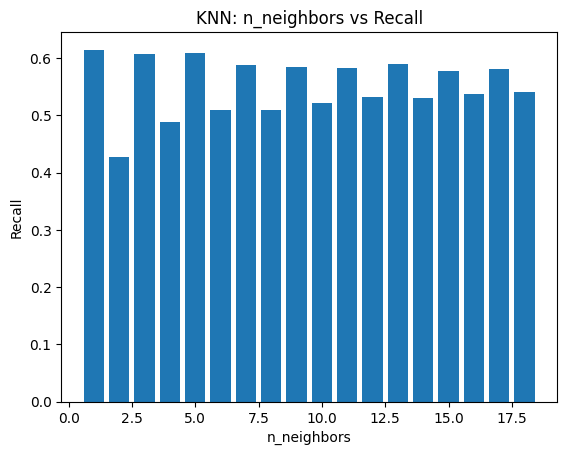

In [34]:
# Tuning KNN
neighbors = range(1, 19)
recall_score_list = []

for n_value in neighbors:
    knn_model = KNeighborsClassifier(n_neighbors=n_value)
    knn_model.fit(X_train, y_train)
    y_pred = knn_model.predict(X_test)
    recall_score_value = recall_score(y_test, y_pred)
    recall_score_list.append(recall_score_value)

import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.bar(neighbors, recall_score_list)
ax.set_xlabel("n_neighbors")
ax.set_ylabel("Recall")
ax.set_title("KNN: n_neighbors vs Recall")
plt.show()

SVM — Support Vector Machine

In [35]:
from sklearn.svm import SVC
from sklearn.metrics import recall_score

X_5k, y_5k = resample(X_cls, y_cls, n_samples=5000, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X_5k, y_5k, test_size=0.2, random_state=42, stratify=y_5k
)

In [36]:
svm_model = SVC(kernel='poly', probability=True)
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [37]:
y_pred = model.predict(X_test)
recall_score_value = recall_score(y_test, y_pred)
print("Recall: ", recall_score_value)

Recall:  0.5154004106776181


[0.3921971252566735]
[0.3921971252566735, 0.5544147843942505]
[0.3921971252566735, 0.5544147843942505, 0.5112936344969199]
[0.3921971252566735, 0.5544147843942505, 0.5112936344969199, 0.4414784394250513]


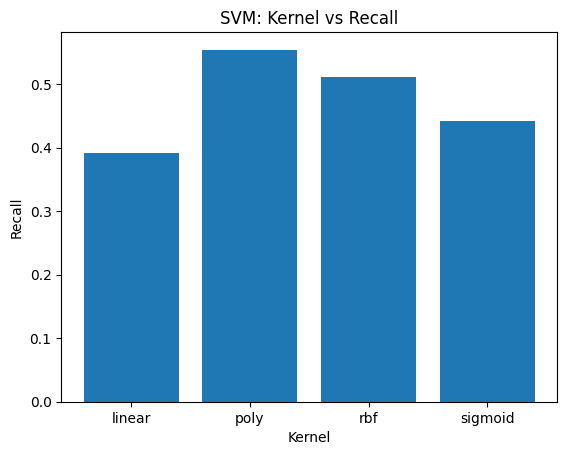

In [38]:
# Tuning SVM
kernel_types = ['linear', 'poly', 'rbf', 'sigmoid']
recall_score_list = []

for kernel_name in kernel_types:
    model = SVC(kernel=kernel_name, probability=True)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    recall_score_value = recall_score(y_test, y_pred)
    recall_score_list.append(recall_score_value)
    print(recall_score_list)

import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.bar(kernel_types, recall_score_list)
ax.set_xlabel("Kernel")
ax.set_ylabel("Recall")
ax.set_title("SVM: Kernel vs Recall")
plt.show()

Logistic Regression


In [39]:
from sklearn.utils import resample
from sklearn.model_selection import train_test_split

X_20k, y_20k = resample(X_cls, y_cls, n_samples=20000, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X_20k, y_20k, test_size=0.2, random_state=42, stratify=y_20k
)

In [40]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

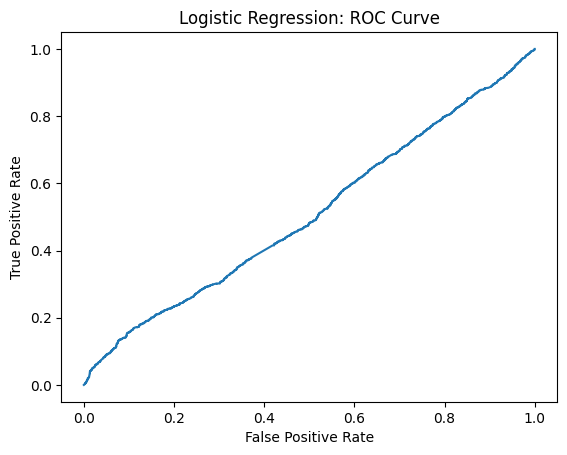

ROC AUC: 0.508197948781539


In [41]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_pred_proba = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots()
ax.plot(fpr, tpr)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Logistic Regression: ROC Curve')
plt.show()

auc_value = roc_auc_score(y_test, y_pred_proba)
print("ROC AUC:", auc_value)

In [42]:
import numpy as np

J = tpr - fpr
optimal_threshold = thresholds[np.argmax(J)]
print("Optimal Threshold:", optimal_threshold)

Optimal Threshold: 0.6044512917422902


In [43]:
from sklearn.metrics import recall_score

y_pred = y_pred_proba > optimal_threshold
recall_score_value = recall_score(y_test, y_pred)
print("Recall:", recall_score_value)

Recall: 0.15446339017051153


In [47]:
import joblib

joblib.dump(knn_model,  "cls_knn.pkl")
joblib.dump(svm_model,  "cls_svm.pkl")
joblib.dump(lr_model,   "cls_logistic.pkl")

print("Classification models saved.")

Classification models saved.
